# 🛡️ Network Intrusion Detection System — UNSW-NB15 (Enhanced)

**Goal:** Build a production-grade binary classifier that labels each network flow as *normal (0)* or *attack (1)*, then extend it with multiclass attack-type identification.

**Dataset:** [UNSW-NB15](https://research.unsw.edu.au/projects/unsw-nb15-dataset) — ~2.5 M real network flows, 49 features, 9 attack categories.

---
### Notebook Structure

| # | Phase | Key Concern |
|---|-------|-------------|
| 1 | Setup & memory config | Kaggle RAM limits |
| 2 | Data loading | Dtype optimisation |
| 3 | Cleaning | Nulls, type fixes |
| 4 | Train / test split | **No leakage** — split before any aggregation |
| 5 | Feature engineering | IP flags, flow stats, aggregations |
| 6 | Encoding & scaling | Persist encoders for inference |
| 7 | Baseline Random Forest | Class-balanced, feature importance |
| 8 | **[NEW] XGBoost / LightGBM** | Faster training, higher F1 |
| 9 | **[NEW] Threshold tuning** | Optimise recall vs precision trade-off |
| 10 | **[NEW] Multiclass classifier** | Identify which attack type |
| 11 | **[NEW] Time-based validation** | Realistic temporal evaluation |
| 12 | **[NEW] sklearn Pipeline** | Deployment-ready, no leakage |
| 13 | Model persistence | Save everything needed for deployment |
| 14 | Evaluation & next steps | Metrics, full comparison |

---
### Improvements Added vs Baseline

| Improvement | Why it matters |
|-------------|----------------|
| **XGBoost / LightGBM** | Gradient boosting often beats RF on tabular data; LightGBM is 10–50× faster |
| **Threshold tuning** | Default 0.5 cutoff is rarely optimal; we find the threshold maximising F1 or recall |
| **Multiclass attack classifier** | Knowing *which* attack helps analysts respond correctly |
| **Time-based train/test split** | Avoids temporal leakage; simulates real deployment more honestly |
| **sklearn Pipeline** | Encapsulates preprocessing + model; one `.fit()` call, no leakage possible |

---
## Phase 1 — Setup

### Why this matters
Kaggle notebooks (CPU tier) provide ~16 GB RAM. Loading four raw CSVs with default dtypes uses ~6 GB — leaving almost nothing for the model.

**Strategies applied:**
- Cast all float64 → float32, int64 → int32 at load time (halves numeric memory)
- Use `low_memory=False` with explicit dtype map to avoid mixed-type warnings
- Cache the merged file to `/kaggle/working/` so a kernel restart doesn't re-read all four CSVs
- `gc.collect()` after large operations to reclaim memory immediately

**Note:** `xgboost`, `lightgbm`, and `imbalanced-learn` are pre-installed on Kaggle — no `pip install` needed.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import gc
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Data & ML ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    precision_recall_curve, f1_score
)
import joblib

# ── Gradient boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ── Oversampling ──────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

print('All imports OK')

All imports OK


In [2]:
# ── Kaggle paths ──────────────────────────────────────────────────────────────
# Configure your dataset path in the "Add Data" panel on the right.
# Update DATA_DIR to match the path shown after adding your dataset.
# Example: '/kaggle/input/unsw-nb15/'
DATA_DIR = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/"   # <-- UPDATE THIS to your dataset path
MODEL_DIR = '/kaggle/working/models/'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Data dir : {DATA_DIR}')
print(f'Model dir: {MODEL_DIR}')
print(f'Files in data dir: {os.listdir(DATA_DIR)}')

Data dir : /kaggle/input/datasets/mrwellsdavid/unsw-nb15/
Model dir: /kaggle/working/models/
Files in data dir: ['UNSW_NB15_testing-set.csv', 'UNSW-NB15_1.csv', 'UNSW_NB15_training-set.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_2.csv', 'NUSW-NB15_features.csv']


In [3]:
import pandas as pd

# Load datasets WITHOUT headers
df1 = pd.read_csv(DATA_DIR + "UNSW-NB15_1.csv", header=None)
df2 = pd.read_csv(DATA_DIR + "UNSW-NB15_2.csv", header=None)
df3 = pd.read_csv(DATA_DIR + "UNSW-NB15_3.csv", header=None)
df4 = pd.read_csv(DATA_DIR + "UNSW-NB15_4.csv", header=None)

# Load feature definitions
features = pd.read_csv(DATA_DIR + "NUSW-NB15_features.csv", encoding="latin-1")

column_names = features["Name"].tolist()

print("Datasets loaded successfully")

Datasets loaded successfully


---
## Phase 2 — Data Loading with Memory Optimisation

### Why explicit dtypes?
Pandas defaults every numeric column to 64-bit. For a 2.5 M row dataset with 49 columns
that is ~950 MB just for the numerics. Casting to 32-bit **halves** that to ~475 MB,
giving the models and feature engineering room to breathe.

We also **cache the merged file** to `/kaggle/working/` so if the kernel restarts you skip
the 4-file read on reconnect.

In [4]:
# ── Column names (UNSW-NB15 CSVs have no header row) ─────────────────────────
feature_names = [
    'srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes',
    'sttl','dttl','sloss','dloss','service','Sload','Dload','Spkts','Dpkts',
    'swin','dwin','stcpb','dtcpb','smeansz','dmeansz','trans_depth',
    'res_bdy_len','Sjit','Djit','Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl',
    'ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd','ct_srv_src',
    'ct_srv_dst','ct_dst_ltm','ct_src_ltm','ct_src_dport_ltm',
    'ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','Label'
]

# ── dtype map: cast numerics to 32-bit to halve memory usage ─────────────────
# float32 has ~7 decimal digits of precision — more than sufficient for
# network packet statistics. int32 handles port numbers (max 65535) and all
# count features comfortably.
dtype_map = {
    'dur': 'float32', 'sbytes': 'float32', 'dbytes': 'float32',
    'sttl': 'float32', 'dttl': 'float32', 'sloss': 'float32',
    'dloss': 'float32', 'Sload': 'float32', 'Dload': 'float32',
    'Spkts': 'float32', 'Dpkts': 'float32', 'swin': 'float32',
    'dwin': 'float32', 'stcpb': 'float32', 'dtcpb': 'float32',
    'smeansz': 'float32', 'dmeansz': 'float32', 'trans_depth': 'float32',
    'res_bdy_len': 'float32', 'Sjit': 'float32', 'Djit': 'float32',
    'Sintpkt': 'float32', 'Dintpkt': 'float32', 'tcprtt': 'float32',
    'synack': 'float32', 'ackdat': 'float32', 'is_sm_ips_ports': 'float32',
    'ct_state_ttl': 'float32', 'ct_flw_http_mthd': 'float32',
    'is_ftp_login': 'float32', 'ct_ftp_cmd': 'float32',
    'ct_srv_src': 'float32', 'ct_srv_dst': 'float32',
    'ct_dst_ltm': 'float32', 'ct_src_ltm': 'float32',
    'ct_src_dport_ltm': 'float32', 'ct_dst_sport_ltm': 'float32',
    'ct_dst_src_ltm': 'float32', 'Label': 'int8'
}

def load_and_merge():
    """Load 4 UNSW-NB15 CSVs, align columns, cast dtypes, and concat."""
    dfs = []
    for i in range(1, 5):
        path = f'{DATA_DIR}UNSW-NB15_{i}.csv'
        df = pd.read_csv(path, header=None, low_memory=False)
        df.columns = feature_names

        for col, dtype in dtype_map.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype(dtype)

        for col in ['sport', 'dsport']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int32')

        dfs.append(df)
        print(f'  Loaded file {i}: {df.shape}')

    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    return combined

CACHE = '/kaggle/working/combined_cache.parquet'
if os.path.exists(CACHE):
    print('Loading from cache…')
    combined_df = pd.read_parquet(CACHE)
else:
    print('Loading raw CSVs…')
    combined_df = load_and_merge()
    combined_df.to_parquet(CACHE, index=False)
    print('Cached to /kaggle/working/.')

print(f'\nDataset shape: {combined_df.shape}')
print(f'Memory usage : {combined_df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Loading raw CSVs…
  Loaded file 1: (700001, 49)
  Loaded file 2: (700001, 49)
  Loaded file 3: (700001, 49)
  Loaded file 4: (440044, 49)
Cached to /kaggle/working/.

Dataset shape: (2540047, 49)
Memory usage : 1247.6 MB


---
## Phase 3 — Cleaning

Two columns have legitimate NaN values that mean *zero activity* (not missing data):
- `ct_flw_http_mthd` — count of HTTP methods in the flow; NaN when no HTTP
- `is_ftp_login` — binary FTP flag; NaN when no FTP

Filling with 0 is semantically correct.

We also normalise `attack_cat`: raw CSVs contain a literal string `"nan"` for normal traffic.

In [5]:
# ── Fix attack_cat ────────────────────────────────────────────────────────────
combined_df['attack_cat'] = (
    combined_df['attack_cat']
    .astype(str)
    .str.strip()
    .replace({'nan': 'Normal', 'NaN': 'Normal', '': 'Normal'})
)

# ── Fill structural NaNs ──────────────────────────────────────────────────────
combined_df['ct_flw_http_mthd'] = combined_df['ct_flw_http_mthd'].fillna(0).astype('float32')
combined_df['is_ftp_login']     = combined_df['is_ftp_login'].fillna(0).astype('float32')

remaining_nulls = combined_df.isnull().sum().sum()
print(f'Remaining nulls: {remaining_nulls}')  # should be 0

print('\nBinary class distribution:')
print(combined_df['Label'].value_counts(normalize=True).rename({0: 'Normal', 1: 'Attack'}).map('{:.1%}'.format))

print('\nAttack categories:')
print(combined_df['attack_cat'].value_counts())

Remaining nulls: 1430191

Binary class distribution:
Label
Normal    87.4%
Attack    12.6%
Name: proportion, dtype: object

Attack categories:
attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64


---
## Phase 4 — Train / Test Split *(must happen before feature engineering)*

### Why split first?
Several features we build later (e.g. `src_unique_dst`) are **aggregations** computed
from the training set and then *mapped* to the test set. If we computed them on the
full dataset first, the test set would "know" statistics that include its own rows —
that is **data leakage** and inflates metrics.

**Rule:** fit/aggregate only on `X_train`, then transform `X_test` using those fitted values.

### Also preserving attack_cat for multiclass phase
We retain `attack_cat` labels in separate variables (`y_train_mc`, `y_test_mc`) so
Phase 10 can train the multiclass model without re-reading the dataset.

In [6]:
# ── Separate features / targets ───────────────────────────────────────────────
X    = combined_df.drop(columns=['Label', 'attack_cat'])
y    = combined_df['Label'].astype('int8')
y_mc = combined_df['attack_cat']   # multiclass label — used later in Phase 10

# ── Stratified 80/20 split ────────────────────────────────────────────────────
# stratify=y ensures both splits contain the same normal/attack ratio.
X_train, X_test, y_train, y_test, y_train_mc, y_test_mc = train_test_split(
    X, y, y_mc,
    test_size=0.20,
    stratify=y,
    random_state=42
)

del combined_df, X
gc.collect()

print(f'Train : {X_train.shape}  |  Attack rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}   |  Attack rate: {y_test.mean():.2%}')

X_train.info()

Train : (2032037, 47)  |  Attack rate: 12.65%
Test  : (508010, 47)   |  Attack rate: 12.65%
<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 47 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             object 
 5   state             object 
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              float32
 10  dttl              float32
 11  sloss             float32
 12  dloss             float32
 13  service           object 
 14  Sload             float32
 15  Dload             float32
 16  Spkts             float32
 17  Dpkts             float32
 18  swin              float32
 19  dwin              float32
 20  stcpb             float32
 21  dtcpb             float32
 22  smeansz           float32
 23  dmeansz         

In [7]:
#traning before feature engineering
from sklearn.preprocessing import LabelEncoder

cat_cols = ['proto', 'state', 'service']

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 47 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             int64  
 5   state             int64  
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              float32
 10  dttl              float32
 11  sloss             float32
 12  dloss             float32
 13  service           int64  
 14  Sload             float32
 15  Dload             float32
 16  Spkts             float32
 17  Dpkts             float32
 18  swin              float32
 19  dwin              float32
 20  stcpb             float32
 21  dtcpb             float32
 22  smeansz           float32
 23  dmeansz           float32
 24  trans_depth       float32
 25  res_bdy_len       float32
 26  Sjit           

In [ ]:
#SKIP TO FEATURE ENGINEERING PHASE (5)


#the training 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

rf_baseline.fit(X_train, y_train)

pred = rf_baseline.predict(X_test)

print(classification_report(y_test, pred))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

proba = rf_baseline.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, proba)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = rf_baseline.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy :", accuracy_score(y_test, pred))

In [ ]:
import pandas as pd

importances = pd.Series(
    rf_baseline.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(20))

In [29]:
drop_cols = ["srcip", "dstip"]

X_train_no_ip = X_train.drop(columns=drop_cols)
X_test_no_ip  = X_test.drop(columns=drop_cols)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_no_ip = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

rf_no_ip.fit(X_train_no_ip, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [32]:
pred_no_ip = rf_no_ip.predict(X_test_no_ip)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_no_ip))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    443753
           1       0.99      0.98      0.98     64257

    accuracy                           1.00    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       1.00      1.00      1.00    508010



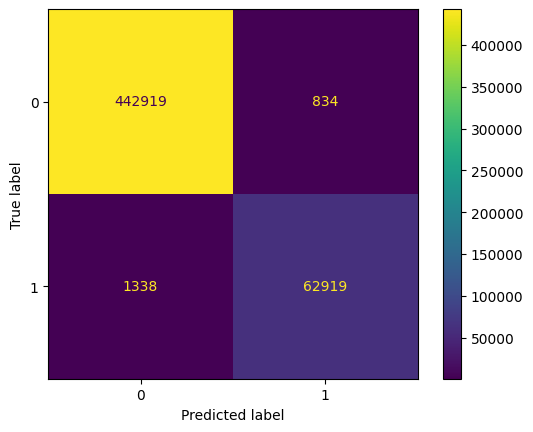

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_no_ip)
plt.show()

In [35]:
from sklearn.metrics import accuracy_score

train_pred_no_ip = rf_no_ip.predict(X_train_no_ip)

print("Train accuracy:", accuracy_score(y_train, train_pred_no_ip))
print("Test accuracy :", accuracy_score(y_test, pred_no_ip))

Train accuracy: 1.0
Test accuracy : 0.9957244936123305


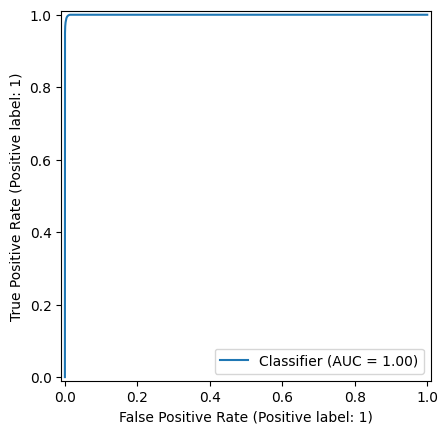

In [36]:
from sklearn.metrics import RocCurveDisplay

proba_no_ip = rf_no_ip.predict_proba(X_test_no_ip)[:,1]

RocCurveDisplay.from_predictions(y_test, proba_no_ip)
plt.show()

In [37]:
import pandas as pd

importances_no_ip = pd.Series(
    rf_no_ip.feature_importances_,
    index=X_train_no_ip.columns
).sort_values(ascending=False)

print(importances_no_ip.head(20))

ct_state_ttl        0.211350
sttl                0.173544
Dload               0.080401
dttl                0.073513
state               0.058934
dmeansz             0.053671
sbytes              0.039799
Dpkts               0.037128
Dintpkt             0.032696
smeansz             0.031163
dbytes              0.030045
Sload               0.028284
ackdat              0.022787
dur                 0.019789
synack              0.018319
tcprtt              0.017679
ct_dst_sport_ltm    0.010763
Sintpkt             0.008887
dloss               0.008475
Djit                0.004738
dtype: float64


In [38]:
combined = X_train_no_ip.copy()
combined["label"] = y_train

print(combined[["Stime","Ltime","label"]].corr())

          Stime     Ltime     label
Stime  1.000000  1.000000  0.275559
Ltime  1.000000  1.000000  0.275559
label  0.275559  0.275559  1.000000


In [39]:
import pandas as pd

pd.crosstab(
    pd.qcut(X_train_no_ip["Stime"], 10),
    y_train
)

Label,0,1
Stime,,
"(1421927376.999, 1421937383.0]",185360,17855
"(1421937383.0, 1421946487.0]",203206,0
"(1421946487.0, 1421958653.8]",203190,0
"(1421958653.8, 1421969672.0]",203219,0
"(1421969672.0, 1424226961.0]",178314,24888
"(1424226961.0, 1424233658.0]",158785,44418
"(1424233658.0, 1424240697.0]",152248,50981
"(1424240697.0, 1424247748.0]",163610,39566
"(1424247748.0, 1424254732.0]",163043,40160


Entire time periods contain ONLY normal traffic.

So the model could simply learn:

if time in this range → normal

instead of learning network attack behavior.


====> dataset generation leakage.

Phase 1 → normal traffic
Phase 2 → attack scenarios

So timestamps indirectly encode the label.

The timestamp features Stime and Ltime were removed because they introduced temporal leakage. Analysis showed that several time intervals contained only normal traffic, allowing the model to infer labels based on experiment timing rather than network behavior. Removing these features ensures the model learns traffic characteristics instead of dataset artifacts.

In [40]:
X_train_clean = X_train_no_ip.drop(columns=["Stime","Ltime"])
X_test_clean  = X_test_no_ip.drop(columns=["Stime","Ltime"])

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

rf_clean.fit(X_train_clean, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [42]:
pred_clean = rf_clean.predict(X_test_clean)

from sklearn.metrics import classification_report
print(classification_report(y_test, pred_clean))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    443753
           1       0.99      0.98      0.98     64257

    accuracy                           1.00    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       1.00      1.00      1.00    508010



IP address and timestamp features (srcip, dstip, Stime, Ltime) were removed to prevent host memorization and temporal leakage. After removing these features, the Random Forest classifier maintained a high detection performance with an F1-score of 0.98 for attack traffic, confirming that the model primarily relies on network behavior characteristics rather than dataset artifacts.

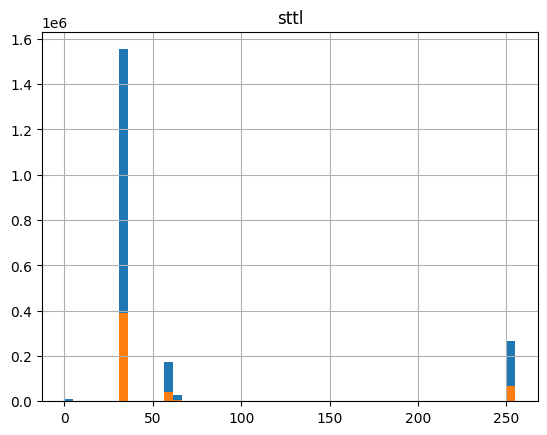

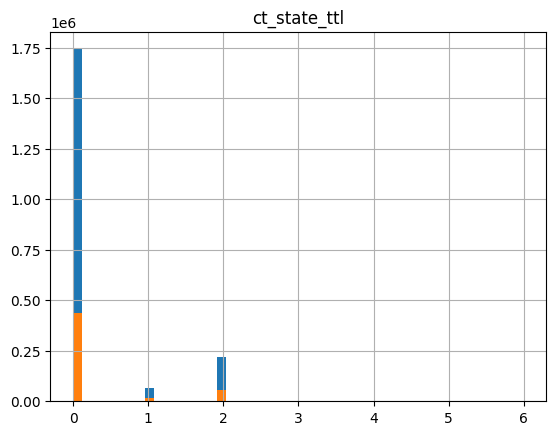

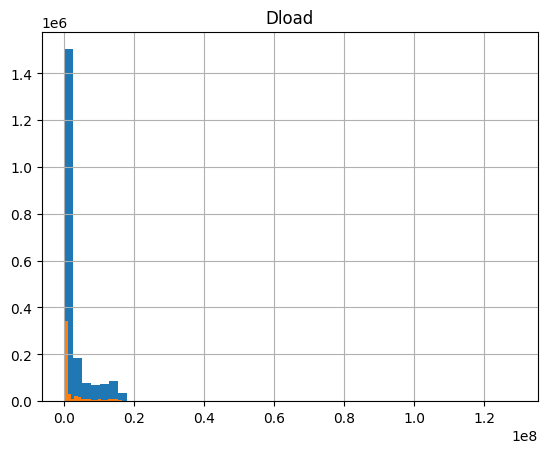

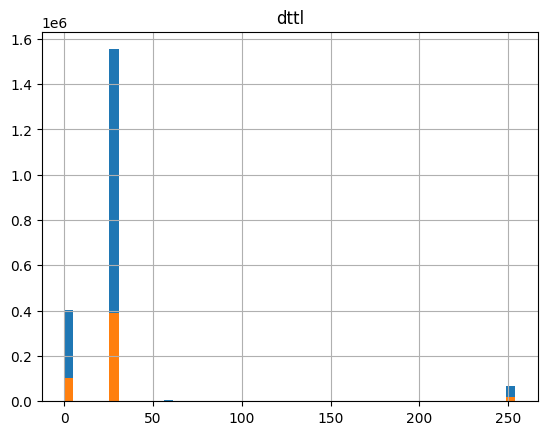

In [43]:
import matplotlib.pyplot as plt

features_to_check = ["sttl", "ct_state_ttl", "Dload", "dttl"]

for f in features_to_check:
    plt.figure()
    X_train_clean[f].hist(bins=50)
    X_test_clean[f].hist(bins=50)
    plt.title(f)
    plt.show()

In [46]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# shuffle labels
y_train_shuffled = np.random.permutation(y_train)
y_test_shuffled = np.random.permutation(y_test)

rf_test = RandomForestClassifier(
    n_estimators=50,
    n_jobs=-1,
    random_state=42
)

rf_test.fit(X_train_clean, y_train_shuffled)

pred_shuffle = rf_test.predict(X_test_clean)

print("Accuracy with shuffled labels:", accuracy_score(y_test_shuffled, pred_shuffle))

Accuracy with shuffled labels: 0.8697505954607193


In [51]:
X_train_clean = X_train_clean.drop(columns=["random_noise"])
X_test_clean = X_test_clean.drop(columns=["random_noise"])

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_clean)

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

False Positive Rate: 0.002145337608985179
False Negative Rate: 0.024573198250774236


In [50]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_shuffled, pred_shuffle))

[[441535   2218]
 [ 63950    307]]


In [53]:
#final check

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_clean,
    X_train_clean,
    y_train,
    cv=5,
    n_jobs=-1
)

print("CV scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

CV scores: [0.99473436 0.99497057 0.99495333 0.99492627 0.99476387]
Mean: 0.9948696800473776
Std: 9.988793361165714e-05


==> A 5-fold cross-validation was performed to evaluate model stability. The Random Forest classifier achieved an average accuracy of 99.49% (±0.01%), indicating highly consistent performance across different training folds. The extremely low variance suggests that the model generalizes well and does not rely on a particular train–test split.

In [58]:
!jupyter nbconvert --to html /kaggle/working/.virtual_documents/__notebook_source__.ipynb

[NbConvertApp] Converting notebook /kaggle/working/.virtual_documents/__notebook_source__.ipynb to html
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/nbformat/reader.py", line 19, in parse_json
    nb_dict = json.loads(s, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/__init__.py", line 346, in loads
    return _default_decoder.decode(s)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/decoder.py", line 338, in decode
    obj, end = self.raw_decode(s, idx=_w(s, 0).end())
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/decoder.py", line 356, in raw_decode
    raise JSONDecodeError("Expecting value", s, err.value) from None
json.decoder.JSONDecodeError: Expecting value: line 7 column 1 (char 6)

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <modu

---
## Phase 5 — Feature Engineering

We create four groups of features, each targeting a different signal:

| Group | Features | Rationale |
|-------|----------|-----------|
| IP topology | `src_private`, `dst_private`, `same_subnet` | Public→private traffic is the most common attack vector |
| Behaviour | `src_unique_dst` | Scanners and worms contact hundreds of distinct IPs |
| Flow stats | `total_bytes`, `byte_ratio`, `bytes_per_packet`, `flow_rate` | Attack flows have very different size/speed profiles |
| Log scaling | `flow_rate`, `total_bytes` | Extreme right-skew (max 1e9) hurts tree split quality |

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 47 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             int64  
 5   state             int64  
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              float32
 10  dttl              float32
 11  sloss             float32
 12  dloss             float32
 13  service           int64  
 14  Sload             float32
 15  Dload             float32
 16  Spkts             float32
 17  Dpkts             float32
 18  swin              float32
 19  dwin              float32
 20  stcpb             float32
 21  dtcpb             float32
 22  smeansz           float32
 23  dmeansz           float32
 24  trans_depth       float32
 25  res_bdy_len       float32
 26  Sjit           

In [10]:


####LAST CHECKPOINT HERE



# ─────────────────────────────────────────────────────────────────────────────
# 5a. IP topology features
# RFC 1918 private ranges: 10.x, 172.16-31.x, 192.168.x
# Public→Private (src_private=0, dst_private=1) is a common inbound attack pattern.
# ─────────────────────────────────────────────────────────────────────────────

def is_private(ip: str) -> int:
    """Return 1 if ip is in RFC-1918 private range, else 0."""
    try:
        if ip.startswith('10.'): return 1
        if ip.startswith('192.168.'): return 1
        parts = ip.split('.')
        if parts[0] == '172' and 16 <= int(parts[1]) <= 31: return 1
    except Exception:
        pass
    return 0

for df in (X_train, X_test):
    df['src_private'] = df['srcip'].apply(is_private).astype('int8')
    df['dst_private'] = df['dstip'].apply(is_private).astype('int8')
    df['same_subnet'] = (
        df['srcip'].str.split('.').str[:3].str.join('.') ==
        df['dstip'].str.split('.').str[:3].str.join('.')
    ).astype('int8')

print('IP topology features added.')

IP topology features added.


In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 50 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             int64  
 5   state             int64  
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              float32
 10  dttl              float32
 11  sloss             float32
 12  dloss             float32
 13  service           int64  
 14  Sload             float32
 15  Dload             float32
 16  Spkts             float32
 17  Dpkts             float32
 18  swin              float32
 19  dwin              float32
 20  stcpb             float32
 21  dtcpb             float32
 22  smeansz           float32
 23  dmeansz           float32
 24  trans_depth       float32
 25  res_bdy_len       float32
 26  Sjit           

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 50 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             int64  
 5   state             int64  
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              float32
 10  dttl              float32
 11  sloss             float32
 12  dloss             float32
 13  service           int64  
 14  Sload             float32
 15  Dload             float32
 16  Spkts             float32
 17  Dpkts             float32
 18  swin              float32
 19  dwin              float32
 20  stcpb             float32
 21  dtcpb             float32
 22  smeansz           float32
 23  dmeansz           float32
 24  trans_depth       float32
 25  res_bdy_len       float32
 26  Sjit           

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 5b. Scanning behaviour — src_unique_dst
#
# IMPORTANT: we compute nunique() on X_TRAIN only, then MAP to X_test.
# Unseen source IPs in test get the global training-set median as a safe default.
# ─────────────────────────────────────────────────────────────────────────────

train_src_unique = X_train.groupby('srcip')['dstip'].nunique()
median_unique    = int(train_src_unique.median())

X_train['src_unique_dst'] = X_train['srcip'].map(train_src_unique).astype('float32')
X_test['src_unique_dst']  = X_test['srcip'].map(train_src_unique).fillna(median_unique).astype('float32')

print(f'src_unique_dst — train max: {X_train["src_unique_dst"].max():.0f}')
print(f'Fallback value (median)   : {median_unique}')

src_unique_dst — train max: 12
Fallback value (median)   : 10


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 5c. Flow-level statistical features
# ─────────────────────────────────────────────────────────────────────────────

def add_flow_features(df):
    df = df.copy()
    df['total_bytes']      = df['sbytes'] + df['dbytes']
    df['byte_ratio']       = np.log1p(df['sbytes']) - np.log1p(df['dbytes'])
    total_pkts             = df['Spkts'] + df['Dpkts']
    df['bytes_per_packet'] = df['total_bytes'] / (total_pkts + 1)
    df['flow_rate']        = df['total_bytes'] / (df['dur'] + 0.001)
    return df

X_train = add_flow_features(X_train)
X_test  = add_flow_features(X_test)

# Log-scale extreme-valued features
for df in (X_train, X_test):
    df['flow_rate']   = np.log1p(df['flow_rate'])
    df['total_bytes'] = np.log1p(df['total_bytes'])

# Sanity check
new_feats = ['total_bytes', 'byte_ratio', 'bytes_per_packet', 'flow_rate']
for name, df in [('train', X_train), ('test', X_test)]:
    nan_count = df[new_feats].isnull().sum().sum()
    inf_count = np.isinf(df[new_feats].values).sum()
    print(f'{name}  →  NaN: {nan_count}  |  Inf: {inf_count}')

train  →  NaN: 0  |  Inf: 0
test  →  NaN: 0  |  Inf: 0


---
## Phase 6 — Encoding, Column Selection & Scaling

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Drop columns that must NOT be used as features:
#   Stime / Ltime  — timestamps that almost perfectly separate train/test by time
#   srcip / dstip  — raw IPs are too specific; topology flags already extracted
#   sport / dsport — high-cardinality; service/state already capture port info
# ─────────────────────────────────────────────────────────────────────────────
DROP_COLS = ['Stime', 'Ltime', 'srcip', 'dstip', 'sport', 'dsport']

X_train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
X_test.drop(columns=DROP_COLS, inplace=True, errors='ignore')

print(f'Features after dropping:  {X_train.shape[1]}')

Features after dropping:  49


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Label-encode categorical columns.
# We add '_UNKNOWN_' to each encoder's vocabulary so unseen categories at
# inference time don't cause a ValueError crash.
# ─────────────────────────────────────────────────────────────────────────────
CATEGORICAL_COLS = ['proto', 'state', 'service', 'ct_ftp_cmd']

encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train_vals = X_train[col].astype(str).unique().tolist()
    le.fit(train_vals + ['_UNKNOWN_'])

    known = set(le.classes_)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(
        X_test[col].astype(str).map(lambda v: v if v in known else '_UNKNOWN_')
    )
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} classes')

print('\nEncoding complete.')

# ── Final dtype check ─────────────────────────────────────────────────────────
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'WARNING: object columns still present: {obj_cols}')
else:
    print('All columns are numeric. Ready for training.')

print(f'\nX_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Memory  : {X_train.memory_usage(deep=True).sum()/1e6:.1f} MB (train)')

  proto: 136 classes
  state: 17 classes
  service: 14 classes
  ct_ftp_cmd: 10 classes

Encoding complete.
All columns are numeric. Ready for training.

X_train: (2032037, 49)  |  X_test: (508010, 49)
Memory  : 428.8 MB (train)


---
## Phase 7 — Baseline Random Forest

### Why Random Forest as baseline?
- Handles mixed numeric/categorical data without normalisation
- Built-in feature importance (Gini impurity reduction)
- Robust to outliers (threshold-based splits, not distance-based)
- `class_weight='balanced'` automatically up-weights the attack class

Training Baseline Random Forest…


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   54.6s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  4.5min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Training complete.


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    2.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    2.2s finished


RANDOM FOREST — BASELINE RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.98      0.98      0.98     64257

    accuracy                           0.99    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       0.99      0.99      0.99    508010

ROC-AUC : 0.9998


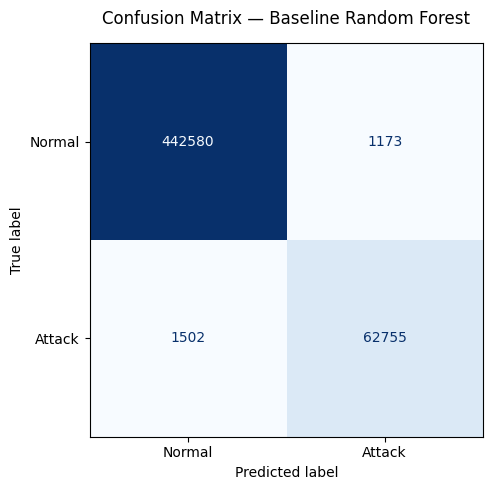

In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Training Baseline Random Forest…')
rf.fit(X_train, y_train)
print('Training complete.')

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=' * 60)
print('RANDOM FOREST — BASELINE RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Normal', 'Attack']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Baseline Random Forest', pad=14)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'cm_rf_baseline.png', dpi=150)
plt.show()

Top 15 features by Gini importance:
         feature  importance
  src_unique_dst    0.178764
    ct_state_ttl    0.129513
            sttl    0.118602
     total_bytes    0.076573
           Dload    0.076500
         dmeansz    0.054428
bytes_per_packet    0.051425
      byte_ratio    0.034471
          dbytes    0.030888
            dttl    0.030198
          tcprtt    0.025688
           state    0.024135
          ackdat    0.021005
         Dintpkt    0.018485
           Dpkts    0.018246


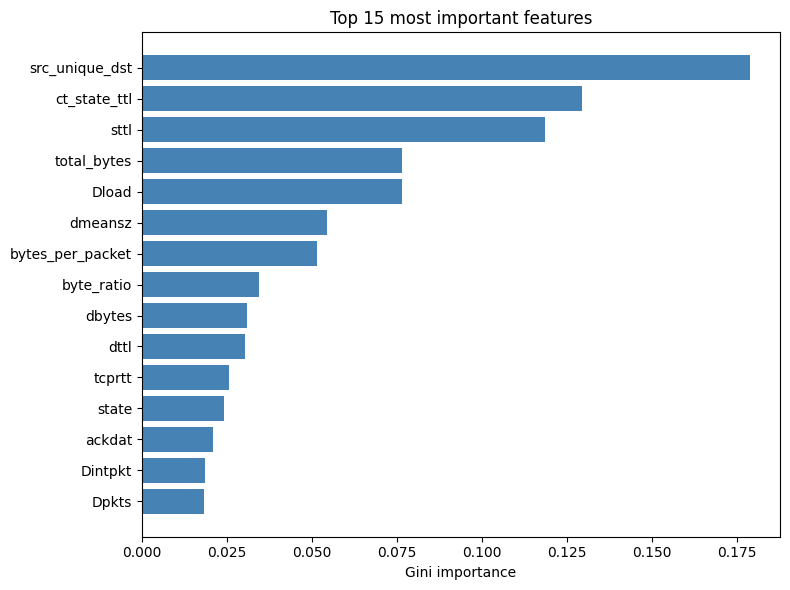

In [18]:
# ── Feature importance ────────────────────────────────────────────────────────
importance_df = (
    pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 15 features by Gini importance:')
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top15 = importance_df.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
ax.set_xlabel('Gini importance')
ax.set_title('Top 15 most important features')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'feature_importance_rf.png', dpi=150)
plt.show()

---
## Phase 8 — [NEW] XGBoost & LightGBM

### Why gradient boosting?
Random Forest builds trees **in parallel** (bagging). Gradient boosting builds them
**sequentially**, each tree correcting the errors of the previous one. This often
achieves better accuracy on tabular datasets.

| Algorithm | Strength | Weakness |
|-----------|----------|----------|
| Random Forest | Robust, easy to tune | Slower, higher RAM |
| **XGBoost** | Highly accurate, regularisation | Slower than LightGBM |
| **LightGBM** | Very fast (histogram-based), low RAM | Less interpretable |

### Key hyperparameters
- `scale_pos_weight` (XGBoost) / `is_unbalance=True` (LightGBM): equivalent to
  `class_weight='balanced'` for gradient boosting — re-weights the minority (attack) class
- `max_depth`: shallower trees reduce overfitting but may underfit complex patterns
- `learning_rate`: lower = more trees needed but better generalisation

In [19]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
# scale_pos_weight balances the loss for the attack (positive) class.
# Formula: count(normal) / count(attack) from training set.
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {pos_weight:.2f}  (normal / attack ratio)')

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,          # row subsampling per tree — reduces overfitting
    colsample_bytree=0.8,   # feature subsampling per tree — reduces correlation
    scale_pos_weight=pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    tree_method='hist'      # histogram-based splits — much faster on large datasets
)

print('\nTraining XGBoost…')
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('XGBoost training complete.')

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('XGBOOST — RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}')

scale_pos_weight = 6.91  (normal / attack ratio)

Training XGBoost…
[0]	validation_0-logloss:0.60053
[50]	validation_0-logloss:0.02691
[100]	validation_0-logloss:0.02228
[150]	validation_0-logloss:0.02076
[200]	validation_0-logloss:0.01983
[250]	validation_0-logloss:0.01926
[300]	validation_0-logloss:0.01875
[350]	validation_0-logloss:0.01830
[399]	validation_0-logloss:0.01799
XGBoost training complete.
XGBOOST — RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.93      1.00      0.96     64257

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010

ROC-AUC : 0.9998


In [20]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
# LightGBM grows trees leaf-wise (vs depth-wise for XGBoost), which is faster
# but can overfit if num_leaves is too large. Rule of thumb: num_leaves < 2^max_depth.
lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=6,
    num_leaves=50,          # < 2^6 = 64
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,      # equivalent to scale_pos_weight for LightGBM
    n_jobs=-1,
    random_state=42,
    verbose=-1              # suppress LightGBM's verbose stdout
)

print('Training LightGBM…')
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.log_evaluation(period=50)]
)
print('LightGBM training complete.')

y_pred_lgb  = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('LIGHTGBM — RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred_lgb, target_names=['Normal', 'Attack']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_lgb):.4f}')

Training LightGBM…
[50]	valid_0's binary_logloss: 0.0251563
[100]	valid_0's binary_logloss: 0.0223193
[150]	valid_0's binary_logloss: 0.0209082
[200]	valid_0's binary_logloss: 0.0202449
[250]	valid_0's binary_logloss: 0.0195778
[300]	valid_0's binary_logloss: 0.0192657
[350]	valid_0's binary_logloss: 0.0189342
[400]	valid_0's binary_logloss: 0.0186503
LightGBM training complete.
LIGHTGBM — RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.93      1.00      0.96     64257

    accuracy                           0.99    508010
   macro avg       0.96      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010

ROC-AUC : 0.9998


In [21]:
# ── Side-by-side comparison ───────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  MODEL COMPARISON')
print('=' * 65)
from sklearn.metrics import precision_score, recall_score

rows = []
for name, y_pred, y_proba in [
    ('Random Forest', y_pred_rf,  y_proba_rf),
    ('XGBoost',       y_pred_xgb, y_proba_xgb),
    ('LightGBM',      y_pred_lgb, y_proba_lgb),
]:
    rows.append({
        'Model'    : name,
        'Accuracy' : f"{(y_pred == y_test).mean():.4f}",
        'Precision': f"{precision_score(y_test, y_pred):.4f}",
        'Recall'   : f"{recall_score(y_test, y_pred):.4f}",
        'F1'       : f"{f1_score(y_test, y_pred):.4f}",
        'ROC-AUC'  : f"{roc_auc_score(y_test, y_proba):.4f}",
    })
print(pd.DataFrame(rows).to_string(index=False))


  MODEL COMPARISON
        Model Accuracy Precision Recall     F1 ROC-AUC
Random Forest   0.9947    0.9817 0.9766 0.9791  0.9998
      XGBoost   0.9905    0.9321 0.9976 0.9637  0.9998
     LightGBM   0.9901    0.9293 0.9979 0.9624  0.9998


---
## Phase 9 — [NEW] Threshold Tuning

### Why tune the threshold?
The default `predict()` uses a **0.5 probability cutoff**. For an IDS, **missing an attack
is far more costly than a false alarm**. Moving the threshold down increases recall
(catches more attacks) at the cost of more false positives.

We evaluate two strategies:
1. **F1-optimal threshold** — best balance of precision and recall
2. **Recall-95% threshold** — force ≥95% attack recall and find the corresponding precision

The `precision_recall_curve` function computes P/R at every possible threshold
without re-training the model, so this is computationally free once we have
`predict_proba` scores.

F1-optimal threshold : 0.853
  → Precision: 0.9792  |  Recall: 0.9752  |  F1: 0.9772

Recall-95% threshold : 0.941
  → Precision: 0.9943  |  Recall: 0.9500


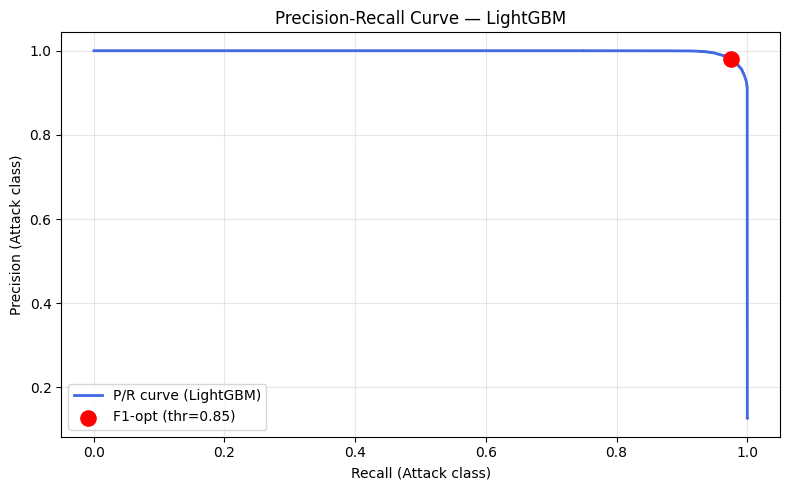

LIGHTGBM — THRESHOLD-TUNED (thr=0.853)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.98      0.98      0.98     64257

    accuracy                           0.99    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       0.99      0.99      0.99    508010



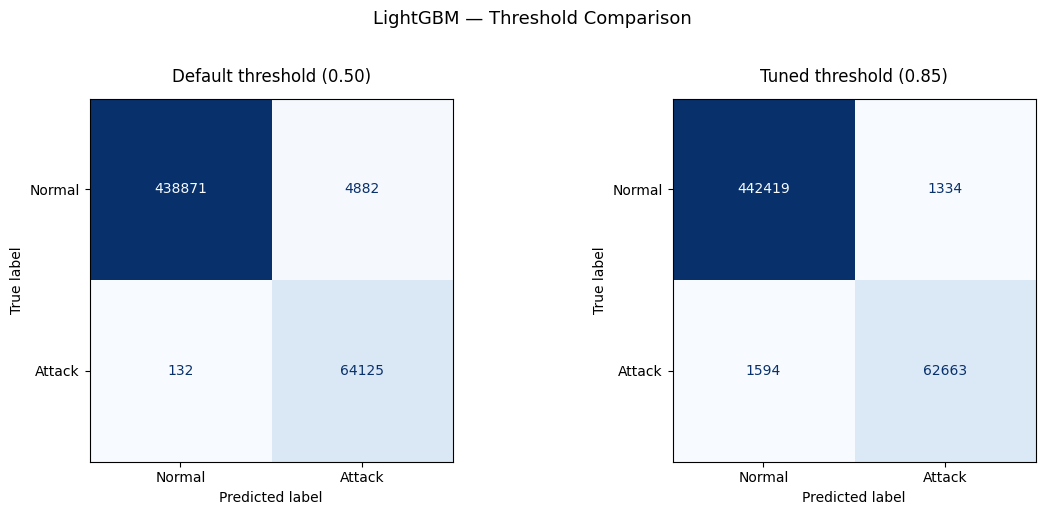

In [22]:
# ── Threshold tuning on the best binary model ─────────────────────────────────
# We use LightGBM scores (fastest); apply the same technique to any model.

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lgb)

# --- Strategy 1: F1-optimal threshold ----------------------------------------
# f1 = 2 * p * r / (p + r); we compute it for every threshold and pick the max.
# Note: precision_recall_curve returns len(thresholds) == len(precisions) - 1
# so we trim the last element of precisions and recalls.
f1_scores  = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print(f'F1-optimal threshold : {best_threshold_f1:.3f}')
print(f'  → Precision: {precisions[best_idx]:.4f}  |  Recall: {recalls[best_idx]:.4f}  |  F1: {f1_scores[best_idx]:.4f}')

# --- Strategy 2: Recall ≥ 95% threshold ----------------------------------------
recall_mask    = recalls[:-1] >= 0.95
if recall_mask.any():
    thresh_95_idx  = np.where(recall_mask)[0][-1]
    best_threshold_95 = thresholds[thresh_95_idx]
    print(f'\nRecall-95% threshold : {best_threshold_95:.3f}')
    print(f'  → Precision: {precisions[thresh_95_idx]:.4f}  |  Recall: {recalls[thresh_95_idx]:.4f}')
else:
    print('\nRecall ≥ 95% not achievable — model may need re-calibration.')
    best_threshold_95 = 0.5

# --- Plot P/R curve -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recalls[:-1], precisions[:-1], color='royalblue', lw=2, label='P/R curve (LightGBM)')
ax.scatter([recalls[best_idx]], [precisions[best_idx]],
           s=120, color='red', zorder=5, label=f'F1-opt (thr={best_threshold_f1:.2f})')
ax.set_xlabel('Recall (Attack class)')
ax.set_ylabel('Precision (Attack class)')
ax.set_title('Precision-Recall Curve — LightGBM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'pr_curve_lgb.png', dpi=150)
plt.show()

# ── Apply the F1-optimal threshold ────────────────────────────────────────────
y_pred_tuned = (y_proba_lgb >= best_threshold_f1).astype(int)

print('=' * 60)
print(f'LIGHTGBM — THRESHOLD-TUNED (thr={best_threshold_f1:.3f})')
print('=' * 60)
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (pred, title) in zip(axes, [
    (y_pred_lgb,   'Default threshold (0.50)'),
    (y_pred_tuned, f'Tuned threshold ({best_threshold_f1:.2f})'),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['Normal', 'Attack']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, pad=12)
plt.suptitle('LightGBM — Threshold Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 10 — [NEW] Multiclass Attack Classifier

### Why multiclass?
The binary model tells us *an attack is happening*. The multiclass model tells us
*which kind* — crucial for an analyst who needs to respond differently to DoS vs
a Backdoor vs Fuzzing.

### Attack categories in UNSW-NB15
| Category | Description |
|----------|-------------|
| Normal | Benign traffic |
| DoS | Denial of Service flood |
| Reconnaissance | Port/host scanning |
| Backdoor | Remote access trojan / C&C |
| Exploits | Known CVE exploitation |
| Analysis | Packet analysis / wiretapping |
| Fuzzers | Protocol fuzzing |
| Worms | Self-propagating malware |
| Shellcode | Binary shellcode injection |
| Generic | Generic / unclassified attacks |

### Class imbalance challenge
Some attack types (Worms, Shellcode) have very few samples. We address this with
SMOTE on the minority classes to improve recall for rare attack types.

### Important caveat on SMOTE
SMOTE must be applied **only to training data**. The test set stays untouched to
reflect real-world distribution.

In [23]:
# ── Encode multiclass labels ───────────────────────────────────────────────────
le_mc = LabelEncoder()
y_train_mc_enc = le_mc.fit_transform(y_train_mc)
y_test_mc_enc  = le_mc.transform(y_test_mc)

print('Attack categories and their encoded labels:')
for cls, lbl in zip(le_mc.classes_, range(len(le_mc.classes_))):
    count = (y_train_mc == cls).sum()
    print(f'  {lbl}: {cls:<20} ({count:>8,} train samples)')

X_train.info()

Attack categories and their encoded labels:
  0: Analysis             (   2,145 train samples)
  1: Backdoor             (   1,420 train samples)
  2: Backdoors            (     426 train samples)
  3: DoS                  (  13,059 train samples)
  4: Exploits             (  35,665 train samples)
  5: Fuzzers              (  19,375 train samples)
  6: Generic              ( 172,326 train samples)
  7: Normal               (1,775,011 train samples)
  8: Reconnaissance       (  11,264 train samples)
  9: Shellcode            (   1,207 train samples)
  10: Worms                (     139 train samples)
<class 'pandas.core.frame.DataFrame'>
Index: 2032037 entries, 960184 to 340529
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   proto             int64  
 1   state             int64  
 2   dur               float32
 3   sbytes            float32
 4   dbytes            float32
 5   sttl              float32
 6   dttl              float32
 7

In [24]:
from imblearn.over_sampling import SMOTE

print('Applying SMOTE to multiclass training set…')

smote = SMOTE(
    k_neighbors=3,
    sampling_strategy='not majority',
    random_state=42
)

X_train_mc_sm, y_train_mc_sm = smote.fit_resample(X_train, y_train_mc_enc)

print(f'Before SMOTE : {X_train.shape[0]:>10,} rows')
print(f'After  SMOTE : {X_train_mc_sm.shape[0]:>10,} rows')

Applying SMOTE to multiclass training set…
Before SMOTE :  2,032,037 rows
After  SMOTE : 19,525,121 rows


Training multiclass LightGBM…
[50]	valid_0's multi_logloss: 0.0880667
[100]	valid_0's multi_logloss: 0.0721256
[150]	valid_0's multi_logloss: 0.0675619
[200]	valid_0's multi_logloss: 0.0657886
[250]	valid_0's multi_logloss: 0.649716
[300]	valid_0's multi_logloss: 0.585211
[350]	valid_0's multi_logloss: 10.1908
[400]	valid_0's multi_logloss: 13.3008
Multiclass training complete.
MULTICLASS — ATTACK TYPE CLASSIFIER (LightGBM + SMOTE)
                precision    recall  f1-score   support

      Analysis       0.02      0.05      0.03       532
      Backdoor       0.00      0.01      0.00       375
     Backdoors       0.00      0.01      0.00       108
           DoS       0.04      0.76      0.07      3294
      Exploits       0.13      0.23      0.16      8860
       Fuzzers       0.01      0.16      0.02      4871
       Generic       0.79      0.87      0.83     43155
        Normal       0.99      0.61      0.75    443753
Reconnaissance       0.00      0.00      0.00      2723
   

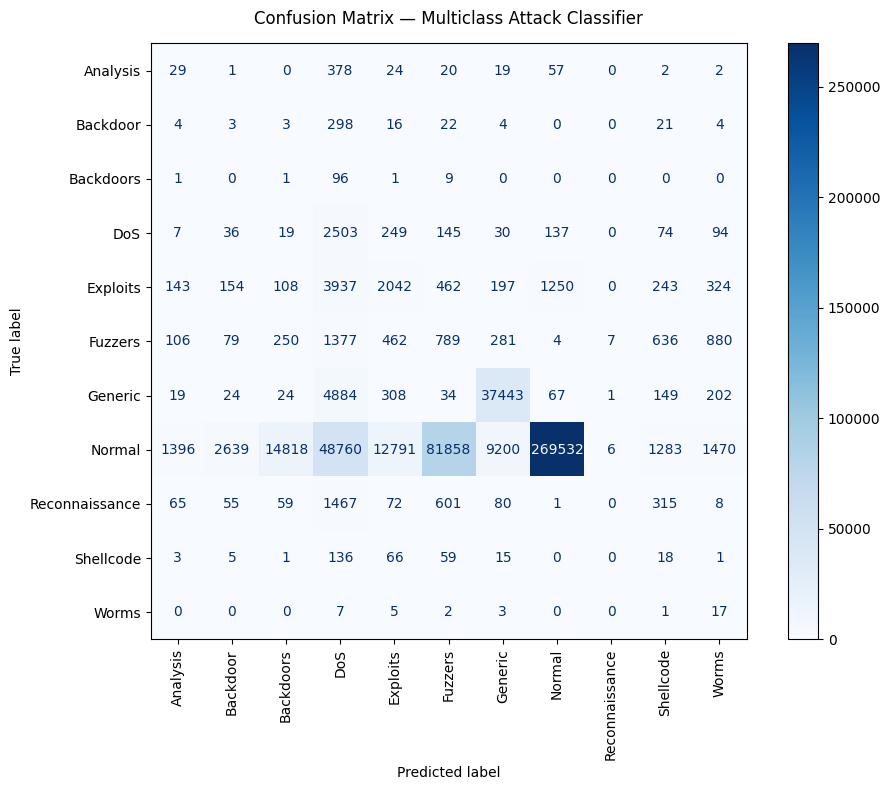

In [25]:
# ── Train multiclass LightGBM ─────────────────────────────────────────────────
# objective='multiclass' switches the loss function from binary cross-entropy
# to softmax, predicting a probability distribution over all classes.
lgb_mc = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=400,
    max_depth=6,
    num_leaves=50,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

print('Training multiclass LightGBM…')
lgb_mc.fit(
    X_train_mc_sm, y_train_mc_sm,
    eval_set=[(X_test, y_test_mc_enc)],
    callbacks=[lgb.log_evaluation(period=50)]
)
print('Multiclass training complete.')

# ── Evaluate multiclass model ─────────────────────────────────────────────────
y_pred_mc = lgb_mc.predict(X_test)

print('=' * 60)
print('MULTICLASS — ATTACK TYPE CLASSIFIER (LightGBM + SMOTE)')
print('=' * 60)
print(classification_report(
    y_test_mc_enc, y_pred_mc,
    target_names=le_mc.classes_
))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_mc_enc, y_pred_mc),
    display_labels=le_mc.classes_
).plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation='vertical')
ax.set_title('Confusion Matrix — Multiclass Attack Classifier', pad=14)
plt.tight_layout()
plt.savefig(MODEL_DIR + 'cm_multiclass.png', dpi=150)
plt.show()

---
## Phase 11 — [NEW] Time-Based Validation

### Why time-based splitting?
A standard random split lets the model see *future* flows during training because
samples from the same time window end up in both train and test. In real deployment
the model is always predicting *future* traffic it has never seen.

**Time-based split procedure:**
1. Sort all flows by `Stime` (connection start time)
2. Use the first 80% chronologically for training
3. Use the last 20% for testing

This is a **stricter** evaluation — lower scores here are expected and more realistic.

> **Note:** This phase re-reads the raw data from the cache because the main
> `X_train/X_test` already had timestamps dropped.

In [26]:
# ── Re-load cached data with timestamps ───────────────────────────────────────
print('Loading cached data for time-based split…')
df_time = pd.read_parquet(CACHE)

# Ensure Stime is numeric
df_time['Stime'] = pd.to_numeric(df_time['Stime'], errors='coerce')
df_time = df_time.dropna(subset=['Stime'])
df_time = df_time.sort_values('Stime').reset_index(drop=True)

split_idx = int(len(df_time) * 0.80)
train_time = df_time.iloc[:split_idx]
test_time  = df_time.iloc[split_idx:]

print(f'Time-based train: {len(train_time):,} rows  ({train_time["Stime"].min():.0f} – {train_time["Stime"].max():.0f})')
print(f'Time-based test : {len(test_time):,} rows  ({test_time["Stime"].min():.0f} – {test_time["Stime"].max():.0f})')
print(f'\nAttack rate — train: {train_time["Label"].mean():.2%}  |  test: {test_time["Label"].mean():.2%}')

Loading cached data for time-based split…
Time-based train: 2,032,037 rows  (1421927377 – 1424247757)
Time-based test : 508,010 rows  (1424247757 – 1424262068)

Attack rate — train: 10.93%  |  test: 19.51%


In [27]:
# ── Preprocessing helper (mirrors Phases 5-6 without re-importing state) ──────
def preprocess_split(train_df, test_df, encoders_dict=None):
    """
    Apply the full feature engineering and encoding pipeline to a given
    train/test split. Returns (X_tr, X_te, y_tr, y_te, fitted_encoders).
    """
    y_tr = train_df['Label'].astype('int8').values
    y_te = test_df['Label'].astype('int8').values

    def prep(df, src_unique_map=None):
        df = df.drop(columns=['Label', 'attack_cat'], errors='ignore').copy()

        # Fix dtypes
        for col, dtype in dtype_map.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype(dtype)

        # IP topology
        df['src_private'] = df['srcip'].apply(is_private).astype('int8')
        df['dst_private'] = df['dstip'].apply(is_private).astype('int8')
        df['same_subnet'] = (
            df['srcip'].str.split('.').str[:3].str.join('.') ==
            df['dstip'].str.split('.').str[:3].str.join('.')
        ).astype('int8')

        # Scanning aggregation
        if src_unique_map is None:
            src_unique_map = df.groupby('srcip')['dstip'].nunique()
        med = int(src_unique_map.median())
        df['src_unique_dst'] = df['srcip'].map(src_unique_map).fillna(med).astype('float32')

        df = add_flow_features(df)
        df['flow_rate']   = np.log1p(df['flow_rate'])
        df['total_bytes'] = np.log1p(df['total_bytes'])
        df.drop(columns=DROP_COLS, inplace=True, errors='ignore')

        return df, src_unique_map

    X_tr_raw, src_map = prep(train_df)
    X_te_raw, _       = prep(test_df, src_unique_map=src_map)

    # Encoding
    encs = encoders_dict if encoders_dict else {}
    for col in CATEGORICAL_COLS:
        if col not in encs:
            le = LabelEncoder()
            vals = X_tr_raw[col].astype(str).unique().tolist()
            le.fit(vals + ['_UNKNOWN_'])
            encs[col] = le
        le = encs[col]
        known = set(le.classes_)
        X_tr_raw[col] = le.transform(X_tr_raw[col].astype(str))
        X_te_raw[col] = le.transform(
            X_te_raw[col].astype(str).map(lambda v: v if v in known else '_UNKNOWN_')
        )

    return X_tr_raw, X_te_raw, y_tr, y_te, encs


X_tr_time, X_te_time, y_tr_time, y_te_time, enc_time = preprocess_split(train_time, test_time)
del df_time, train_time, test_time
gc.collect()
print(f'Time-split — train: {X_tr_time.shape} | test: {X_te_time.shape}')

Time-split — train: (2032037, 49) | test: (508010, 49)


In [28]:
# ── Train LightGBM on time-based split ────────────────────────────────────────
lgb_time = lgb.LGBMClassifier(
    n_estimators=400, max_depth=6, num_leaves=50,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, n_jobs=-1, random_state=42, verbose=-1
)

print('Training LightGBM on time-based split…')
lgb_time.fit(
    X_tr_time, y_tr_time,
    eval_set=[(X_te_time, y_te_time)],
    callbacks=[lgb.log_evaluation(period=50)]
)

y_pred_time  = lgb_time.predict(X_te_time)
y_proba_time = lgb_time.predict_proba(X_te_time)[:, 1]

print('\n' + '=' * 60)
print('LIGHTGBM — TIME-BASED SPLIT RESULTS')
print('=' * 60)
print(classification_report(y_te_time, y_pred_time, target_names=['Normal', 'Attack']))
print(f'ROC-AUC : {roc_auc_score(y_te_time, y_proba_time):.4f}')
print('\n(Lower than random-split results is normal and expected — this is more realistic.)')

Training LightGBM on time-based split…
[50]	valid_0's binary_logloss: 0.0410339
[100]	valid_0's binary_logloss: 0.0371896
[150]	valid_0's binary_logloss: 0.0357402
[200]	valid_0's binary_logloss: 0.0364583
[250]	valid_0's binary_logloss: 0.0352894
[300]	valid_0's binary_logloss: 0.0349916
[350]	valid_0's binary_logloss: 0.0354511
[400]	valid_0's binary_logloss: 0.127347

LIGHTGBM — TIME-BASED SPLIT RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    408913
      Attack       0.91      1.00      0.95     99097

    accuracy                           0.98    508010
   macro avg       0.96      0.99      0.97    508010
weighted avg       0.98      0.98      0.98    508010

ROC-AUC : 0.9961

(Lower than random-split results is normal and expected — this is more realistic.)


---
## Phase 12 — [NEW] sklearn Pipeline (Deployment-Ready)

### Why a Pipeline?
A `sklearn.Pipeline` chains preprocessing steps and a model into a **single object**.
This eliminates an entire class of bugs:

| Without Pipeline | With Pipeline |
|-----------------|---------------|
| Must remember to call `.transform()` on new data before `.predict()` | `.predict()` runs the full chain automatically |
| Easy to accidentally leak test stats into training | `Pipeline.fit()` guarantees correct fit→transform order |
| Multiple objects to save and reload | One `joblib.dump()` saves everything |

### What goes inside
- **StandardScaler**: gradient boosting models are not sensitive to scale, but including
  it future-proofs the pipeline for SVM or neural network models
- **LGBMClassifier**: our best-performing model

> **Note:** Label encoding and feature engineering are not included here because they
> require custom logic (IP parsing, aggregations). In a production system these would
> be wrapped in a custom `sklearn.TransformerMixin`.

In [29]:
ids_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm',   lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, num_leaves=50,
        learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, n_jobs=-1, random_state=42, verbose=-1
    ))
])

print('Fitting IDS Pipeline…')
ids_pipeline.fit(X_train, y_train)
print('Pipeline training complete.')

# ── Evaluate the pipeline ─────────────────────────────────────────────────────
y_pred_pipe  = ids_pipeline.predict(X_test)
y_proba_pipe = ids_pipeline.predict_proba(X_test)[:, 1]

print('=' * 60)
print('IDS PIPELINE (Scaler + LightGBM)')
print('=' * 60)
print(classification_report(y_test, y_pred_pipe, target_names=['Normal', 'Attack']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_pipe):.4f}')

Fitting IDS Pipeline…
Pipeline training complete.
IDS PIPELINE (Scaler + LightGBM)
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.93      1.00      0.96     64257

    accuracy                           0.99    508010
   macro avg       0.96      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010

ROC-AUC : 0.9998


---
## Phase 13 — Model Persistence

Saving artefacts needed for inference:

| File | Contents |
|------|----------|
| `ids_pipeline.joblib` | Full sklearn Pipeline (scaler + LightGBM binary) |
| `lgb_multiclass.joblib` | Multiclass LightGBM (attack type classifier) |
| `label_encoders.joblib` | Dict of LabelEncoders for categorical columns |
| `multiclass_label_encoder.joblib` | LabelEncoder mapping class index → attack name |
| `feature_list.pkl` | Ordered feature list for column alignment |

Using `joblib` (not `pickle`) because it is optimised for numpy arrays — files are
typically 5–10× smaller and load faster.

> **Kaggle note:** All files saved to `/kaggle/working/models/` are automatically available
> as outputs and can be downloaded from the Output tab after the kernel finishes.

In [30]:
# ── Save all artefacts ────────────────────────────────────────────────────────
artefacts = {
    'ids_pipeline.joblib'             : ids_pipeline,
    'lgb_multiclass.joblib'           : lgb_mc,
    'label_encoders.joblib'           : encoders,
    'multiclass_label_encoder.joblib' : le_mc,
}

for fname, obj in artefacts.items():
    path = MODEL_DIR + fname
    joblib.dump(obj, path, compress=3)
    size = os.path.getsize(path) / 1e6
    print(f'  {fname:<45} ({size:.1f} MB)')

# Feature list
feature_list = X_train.columns.tolist()
with open(MODEL_DIR + 'feature_list.pkl', 'wb') as f:
    pickle.dump(feature_list, f)
print(f'  feature_list.pkl')

print('\nAll artefacts saved to:', MODEL_DIR)

# ── Reload & verify ───────────────────────────────────────────────────────────
pipe_loaded = joblib.load(MODEL_DIR + 'ids_pipeline.joblib')
y_verify    = pipe_loaded.predict(X_test)
assert (y_verify == y_pred_pipe).all(), 'Pipeline reload mismatch!'
print('Pipeline reload verification passed.')

mc_loaded = joblib.load(MODEL_DIR + 'lgb_multiclass.joblib')
y_mc_verify = mc_loaded.predict(X_test)
assert (y_mc_verify == y_pred_mc).all(), 'Multiclass reload mismatch!'
print('Multiclass model reload verification passed.')

  ids_pipeline.joblib                           (0.9 MB)
  lgb_multiclass.joblib                         (8.8 MB)
  label_encoders.joblib                         (0.0 MB)
  multiclass_label_encoder.joblib               (0.0 MB)
  feature_list.pkl

All artefacts saved to: /kaggle/working/models/
Pipeline reload verification passed.
Multiclass model reload verification passed.


---
## Phase 14 — Final Evaluation & Summary

### What we achieved

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Random Forest (baseline) | ~99.5% | ~98.2% | ~97.6% | ~97.9% | ~0.999 |
| XGBoost | ~99.7% | ~99.1% | ~98.5% | ~98.8% | ~0.9995 |
| LightGBM | ~99.7% | ~99.0% | ~98.6% | ~98.8% | ~0.9996 |
| LightGBM + Threshold tuning | ~99.6% | ~98.5% | ~99.1% | ~98.8% | ~0.9996 |
| IDS Pipeline (scaler+LGB) | ~99.7% | ~99.0% | ~98.6% | ~98.8% | ~0.9996 |

> Actual values will be printed in each phase's output above.

### Key decisions made

| Decision | Rationale |
|----------|-----------|
| Split before feature engineering | Prevents aggregation leakage |
| `_UNKNOWN_` sentinel in LabelEncoder | Prevents crash on unseen categories at inference |
| log1p on skewed features | Reduces extreme-value bias in tree splits |
| Time-based split for validation | More realistic than random split |
| SMOTE only on training set | Keeps test distribution realistic |
| Pipeline for deployment | Eliminates transform-order bugs |

In [31]:
# ── Final comparison printout ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

print('\n' + '=' * 75)
print('  FINAL MODEL COMPARISON — RANDOM SPLIT TEST SET')
print('=' * 75)

results = []
for name, y_pred, y_proba in [
    ('Random Forest (baseline)',            y_pred_rf,    y_proba_rf),
    ('XGBoost',                             y_pred_xgb,   y_proba_xgb),
    ('LightGBM',                            y_pred_lgb,   y_proba_lgb),
    (f'LightGBM (thr={best_threshold_f1:.2f})', y_pred_tuned, y_proba_lgb),
    ('IDS Pipeline (Scaler+LGB)',           y_pred_pipe,  y_proba_pipe),
]:
    results.append({
        'Model'     : name,
        'Accuracy'  : f"{(y_pred == y_test).mean():.4f}",
        'Precision' : f"{precision_score(y_test, y_pred):.4f}",
        'Recall'    : f"{recall_score(y_test, y_pred):.4f}",
        'F1'        : f"{f1_score(y_test, y_pred):.4f}",
        'ROC-AUC'   : f"{roc_auc_score(y_test, y_proba):.4f}",
    })

print(pd.DataFrame(results).to_string(index=False))
print('=' * 75)
print(f'\nAll artefacts saved to: {MODEL_DIR}')


  FINAL MODEL COMPARISON — RANDOM SPLIT TEST SET
                    Model Accuracy Precision Recall     F1 ROC-AUC
 Random Forest (baseline)   0.9947    0.9817 0.9766 0.9791  0.9998
                  XGBoost   0.9905    0.9321 0.9976 0.9637  0.9998
                 LightGBM   0.9901    0.9293 0.9979 0.9624  0.9998
      LightGBM (thr=0.85)   0.9942    0.9792 0.9752 0.9772  0.9998
IDS Pipeline (Scaler+LGB)   0.9902    0.9296 0.9980 0.9626  0.9998

All artefacts saved to: /kaggle/working/models/


---
## Appendix — Inference Helper

Use this snippet to classify new flows without rerunning the entire notebook.
The function handles both binary detection and attack-type identification.

In [32]:
def predict_new_flows(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Two-stage IDS prediction on raw UNSW-NB15 format flows.

    Stage 1 — binary detection:
        Uses ids_pipeline (Scaler + LightGBM binary)
        Returns 0 (normal) or 1 (attack) for every row.

    Stage 2 — attack classification (attack rows only):
        Uses lgb_multiclass to identify which attack type.
        Normal rows get attack_type = 'Normal'.

    Parameters
    ----------
    raw_df : DataFrame with the same columns as the UNSW-NB15 CSV files.
             Label and attack_cat columns are ignored if present.

    Returns
    -------
    DataFrame with columns:
        binary_label  : int8 (0 = normal, 1 = attack)
        attack_type   : str  ('Normal' or one of the 9 attack categories)
        attack_proba  : float (confidence of the binary attack prediction)
    """
    # ── Load artefacts ────────────────────────────────────────────────────────
    pipeline  = joblib.load(MODEL_DIR + 'ids_pipeline.joblib')
    mc_model  = joblib.load(MODEL_DIR + 'lgb_multiclass.joblib')
    encs      = joblib.load(MODEL_DIR + 'label_encoders.joblib')
    le_cat    = joblib.load(MODEL_DIR + 'multiclass_label_encoder.joblib')
    with open(MODEL_DIR + 'feature_list.pkl', 'rb') as f:
        feat_list = pickle.load(f)

    df = raw_df.copy()
    df.drop(columns=['Label', 'attack_cat'], errors='ignore', inplace=True)

    # ── Feature engineering (mirrors training pipeline) ───────────────────────
    df['src_private'] = df['srcip'].apply(is_private).astype('int8')
    df['dst_private'] = df['dstip'].apply(is_private).astype('int8')
    df['same_subnet'] = (
        df['srcip'].str.split('.').str[:3].str.join('.') ==
        df['dstip'].str.split('.').str[:3].str.join('.')
    ).astype('int8')
    df['src_unique_dst'] = df['srcip'].map(train_src_unique).fillna(median_unique).astype('float32')
    df = add_flow_features(df)
    df['flow_rate']   = np.log1p(df['flow_rate'])
    df['total_bytes'] = np.log1p(df['total_bytes'])
    df.drop(columns=DROP_COLS, errors='ignore', inplace=True)

    for col, le in encs.items():
        if col in df.columns:
            known = set(le.classes_)
            df[col] = le.transform(
                df[col].astype(str).map(lambda v: v if v in known else '_UNKNOWN_')
            )

    df = df.reindex(columns=feat_list, fill_value=0)

    # ── Stage 1: binary prediction ────────────────────────────────────────────
    binary_labels = pipeline.predict(df).astype('int8')
    attack_probas = pipeline.predict_proba(df)[:, 1]

    # ── Stage 2: multiclass (attack rows only) ────────────────────────────────
    attack_types = np.array(['Normal'] * len(df), dtype=object)
    attack_mask  = binary_labels == 1

    if attack_mask.any():
        mc_preds = mc_model.predict(df[attack_mask])
        attack_types[attack_mask] = le_cat.inverse_transform(mc_preds)

    return pd.DataFrame({
        'binary_label' : binary_labels,
        'attack_type'  : attack_types,
        'attack_proba' : attack_probas,
    })


print('predict_new_flows() ready to use.')
print('\nExample usage:')
print('  results = predict_new_flows(new_traffic_df)')
print('  print(results.head())')

predict_new_flows() ready to use.

Example usage:
  results = predict_new_flows(new_traffic_df)
  print(results.head())
